## Predicting Job Change Interest – Candidate Prioritization Model

## Objective

The goal of this project is to prepare and optimize a dataset that will be used to predict whether a candidate is interested in changing jobs.

The company wants to prioritize candidates who are actively looking for new opportunities (target = 1). By predicting this ahead of time, recruiters can reduce time and cost spent reaching out to candidates who are not interested.

Before building models like Logistic Regression, Decision Trees, or Random Forest, it is critical that the dataset is properly cleaned, explored, and engineered.

In this notebook, I will:

• Carefully review the raw dataset before making any changes  
• Perform data preprocessing (missing values, duplicates, inconsistencies, outliers)  
• Conduct exploratory data analysis (EDA)  
• Apply feature engineering techniques where appropriate  
• Prepare the final dataset for model building  

The focus here is not just on cleaning data, but showing understanding of why each step is necessary.

## Data Dictionary

Below is a summary of each feature in the dataset:

- enrollee_id: Unique ID for the candidate  
- city: City code  
- city_development_index: Development index of the city (scaled)  
- gender: Gender of the candidate  
- relevent_experience: Relevant experience indicator  
- enrolled_university: Type of university course enrolled (if any)  
- education_level: Education level  
- major_discipline: Candidate’s major  
- experience: Total years of experience  
- company_size: Number of employees in current company  
- company_type: Type of current employer  
- lastnewjob: Years between previous and current job  
- training_hours: Training hours completed  
- target:  
    - 0 = Not looking for job change  
    - 1 = Looking for job change  

The target variable is binary classification.

## Load Required Libraries

In [6]:
# Basic data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Model preparation tools (used later)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load Data

In [8]:
# Load dataset using full file path
df = pd.read_csv(r"C:\Users\Caden\Downloads\job_candidates.csv")

# Preview first few rows
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## Data Overview

In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [11]:
# Summary statistics for numeric columns
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [12]:
# Target distribution
df['target'].value_counts(normalize=True)

target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64

### Data Overview Observations

After reviewing the dataset structure and summary statistics, several important patterns stand out.

The dataset contains 19,158 observations and 14 features. There are no immediate structural issues, but multiple categorical columns contain missing values, particularly:

- gender  
- enrolled_university  
- education_level  
- major_discipline  
- company_size  
- company_type  
- last_new_job  

The target variable is clearly imbalanced:
- Approximately 75% of candidates are not looking for a job change (0)
- Approximately 25% are looking for a job change (1)

This imbalance will need to be considered later when evaluating model performance, especially when looking at recall and precision.

The numerical features show some important characteristics:
- city_development_index is tightly distributed between 0.448 and 0.949.
- training_hours has a wide range (1 to 336) and appears right-skewed, suggesting potential outliers.
- enrollee_id appears numeric but is simply a unique identifier and will not be useful for prediction.

Additionally, experience and last_new_job are stored as object types and contain non-numeric values such as ">20", "<1", and "never". These will require careful transformation before modeling.

At this stage, no changes have been made. The goal here was strictly to understand the dataset before beginning preprocessing.

## Data Preprocessing

### Duplicate Data

In [13]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

There are no duplicate rows in the dataset. 

Since no exact duplicates exist, no rows will be removed at this stage.

### Missing Values

In [14]:
# Count missing values and percentage
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

missing_summary

,Missing Count,Missing %
company_type,6140,32.049274
company_size,5938,30.994885
gender,4508,23.530640
major_discipline,2813,14.683161
education_level,460,2.401086
last_new_job,423,2.207955
enrolled_university,386,2.014824
experience,65,0.339284
enrollee_id,0,0.000000
city,0,0.000000


### Handling Missing Values

After reviewing the missing value percentages, I decided not to drop rows since several important features contain 20–32% missing values.

Instead, for categorical variables, missing values will be treated as their own category labeled "Unknown". 

In HR datasets, missing company information may itself carry predictive signal, so preserving those rows is preferable to dropping them.

For very small missing percentages (under 3%), I will also fill with "Unknown" for consistency rather than dropping observations.

In [15]:
# Drop enrollee_id (identifier, not predictive)
df = df.drop(columns=["enrollee_id"])

# Fill categorical missing values with "Unknown"
categorical_cols = df.select_dtypes(include="object").columns

df[categorical_cols] = df[categorical_cols].fillna("Unknown")

df.isnull().sum()

city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

### Cleaning Experience Column

The `experience` column is stored as text and contains values like ">20", "<1", and sometimes "Unknown".

To make it usable for ML:
- ">20" → 21
- "<1" → 0
- "Unknown" → missing (NaN) for now (we’ll decide how to handle missing values right after this)
- everything else → converted to numeric

In [17]:
# Clean experience column (handles >20, <1, and Unknown)
df["experience"] = df["experience"].replace({
    ">20": 21,
    "<1": 0,
    "Unknown": np.nan
})

# Convert to numeric safely
df["experience"] = pd.to_numeric(df["experience"], errors="coerce")

# Quick check
df["experience"].describe()

count    19093.000000
mean        10.100141
std          6.777024
min          0.000000
25%          4.000000
50%          9.000000
75%         16.000000
max         21.000000
Name: experience, dtype: float64

In [19]:
# Clean last_new_job column
df["last_new_job"] = df["last_new_job"].replace({
    ">4": 5,
    "never": 0
})

df["last_new_job"] = pd.to_numeric(df["last_new_job"], errors="coerce")

df["last_new_job"].describe()

count    18735.000000
mean         2.000427
std          1.675596
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max          5.000000
Name: last_new_job, dtype: float64

In [20]:
df.dtypes

city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                float64
company_size               object
company_type               object
last_new_job              float64
training_hours              int64
target                    float64
dtype: object

In [21]:
df[["experience", "last_new_job"]].isna().sum()

experience       65
last_new_job    423
dtype: int64

## Missing Values (After Type Fixes)

Now that `experience` and `last_new_job` were converted into numeric features, some values became missing:

- `experience`: 65 missing (came from "Unknown")
- `last_new_job`: 423 missing (values that were blank/unknown after converting)

Instead of dropping rows (which would throw away good data), I’m going to impute:

- For numeric columns (`experience`, `last_new_job`): fill with the **median**
  - Median is a safe default because it’s less sensitive to outliers than the mean.
- For categorical columns (like `gender`, `company_size`, etc.): fill with the **mode** or an `"Unknown"` label depending on what makes the most sense.

In [22]:
# Impute missing numeric values using median (robust to outliers)
df["experience"] = df["experience"].fillna(df["experience"].median())
df["last_new_job"] = df["last_new_job"].fillna(df["last_new_job"].median())

df[["experience", "last_new_job"]].isna().sum()

experience      0
last_new_job    0
dtype: int64

In [23]:
# Check missing values for categorical columns
cat_cols = df.select_dtypes(include="object").columns
missing_cat = df[cat_cols].isna().sum().sort_values(ascending=False)
missing_cat[missing_cat > 0]

Series([], dtype: int64)

## Duplicate and Data Consistency Check

Before moving into EDA, I want to verify:

- No duplicate rows exist
- No unexpected inconsistencies remain
- The dataset structure is stable

This ensures the modeling process is built on reliable data.

In [24]:
# Check duplicate rows
df.duplicated().sum()

np.int64(49)

# Exploratory Data Analysis (EDA)

The goal of this section is to explore the dataset to better understand:

- The distribution of the target variable
- Patterns within numeric features
- Relationships between variables
- Potential outliers
- Any early signals that may impact modeling decisions

EDA helps guide feature engineering and model selection.

## Univariate Analysis
Univariate analysis = looking at one column at a time to understand its distribution and spot anything weird early.

### Target Variable Distribution
First thing I want to check is how balanced the target is. If it's imbalanced, accuracy alone can be misleading later.

,Count,Percent
target,,
0.0,14381,75.07
1.0,4777,24.93


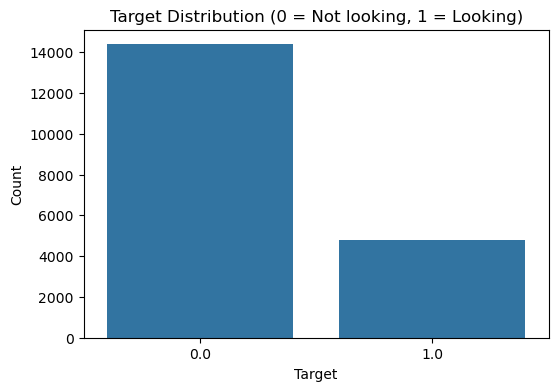

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Target counts + percentages
target_counts = df["target"].value_counts()
target_pct = df["target"].value_counts(normalize=True) * 100

display(pd.DataFrame({"Count": target_counts, "Percent": target_pct.round(2)}))

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution (0 = Not looking, 1 = Looking)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

### Numeric Feature Distributions
Here I’m checking the numeric columns to see:
- general shape (normal vs skewed)
- whether there are extreme values / potential outliers
- whether scaling might matter later (especially for logistic regression)

In [28]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_cols

['city_development_index',
 'experience',
 'last_new_job',
 'training_hours',
 'target']

In [29]:
# Summary stats for numeric features
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
experience,19158.0,10.096409,6.765820,0.000,4.00,9.000,16.00,21.000
last_new_job,19158.0,1.978338,1.663502,0.000,1.00,1.000,3.00,5.000
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


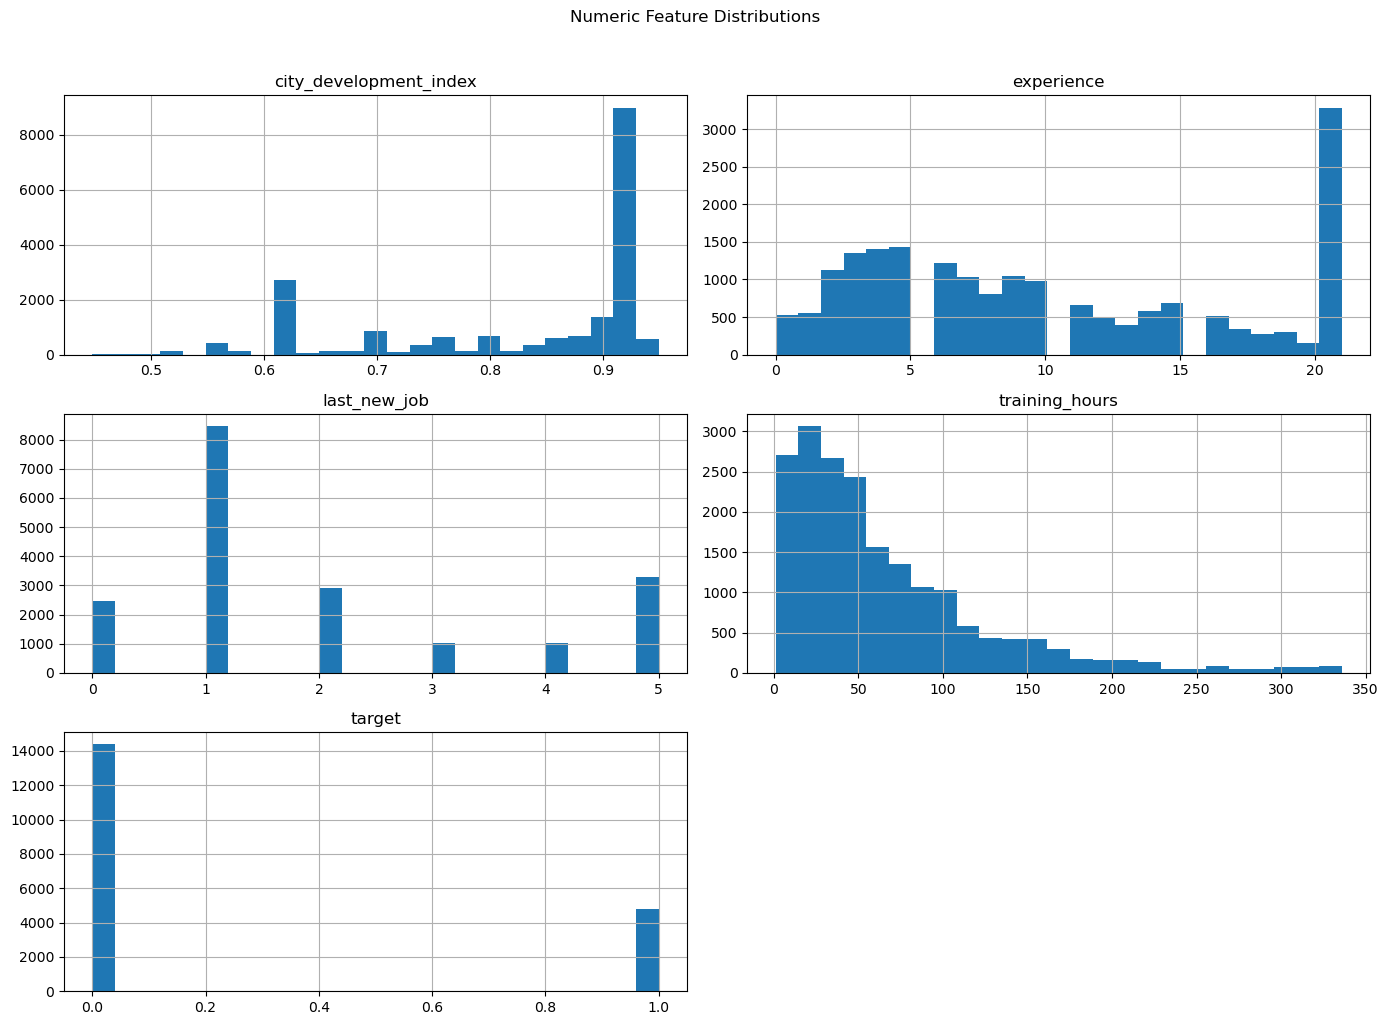

In [30]:
# Histograms for numeric features
df[numeric_cols].hist(figsize=(14,10), bins=25)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

### Outlier Check (Numeric Features)
I’m not automatically deleting outliers, but I want to *see* them.

Sometimes outliers are real behavior (ex: someone with a ton of training hours), and deleting them could hurt the model.
So for now I’m just visualizing them with boxplots.

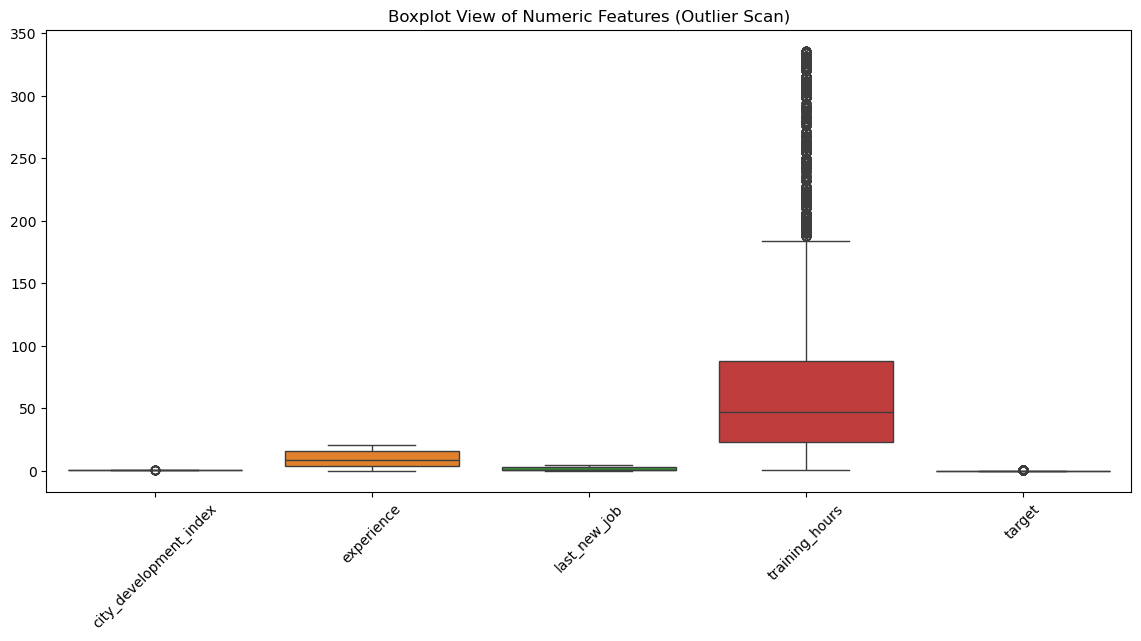

In [31]:
# Boxplots for numeric columns (quick outlier view)
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot View of Numeric Features (Outlier Scan)")
plt.xticks(rotation=45)
plt.show()

### Categorical Feature Distributions
These columns are text/object columns (categories). I want to see:
- most common categories
- if "Unknown" / missing style values exist
- whether some categories are super rare (might need grouping later)

In [32]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['city',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'company_size',
 'company_type']

In [33]:
# Show top categories for each categorical column
for col in cat_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).head(10))


--- city ---


city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
city_136     586
city_67      431
city_75      305
city_102     304
city_104     301
Name: count, dtype: int64


--- gender ---


gender
Male       13221
Unknown     4508
Female      1238
Other        191
Name: count, dtype: int64


--- relevent_experience ---


...

major_discipline
STEM               14492
Unknown             2813
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64


--- company_size ---


company_size
Unknown      5938
50-99        3083
100-500      2571
10000+       2019
10/49        1471
1000-4999    1328
<10          1308
500-999       877
5000-9999     563
Name: count, dtype: int64


--- company_type ---


company_type
Pvt Ltd                9817
Unknown                6140
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64

## Multivariate / Bivariate Analysis
Now I’m looking at relationships:
- numeric vs target
- categorical vs target
- numeric vs numeric correlation patterns

This helps me see which variables may matter and which ones might be noise.

### Numeric Features vs Target
Here I compare numeric distributions split by target (0 vs 1).  
If one class consistently has higher/lower values, that feature might be useful.

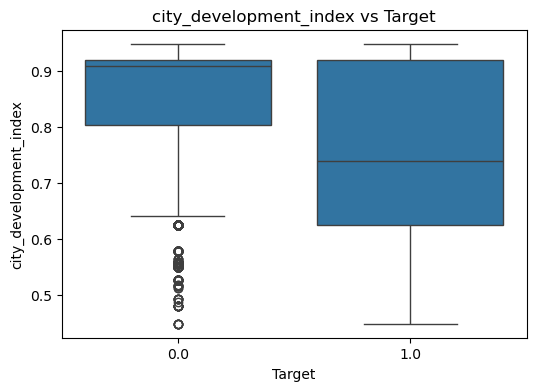

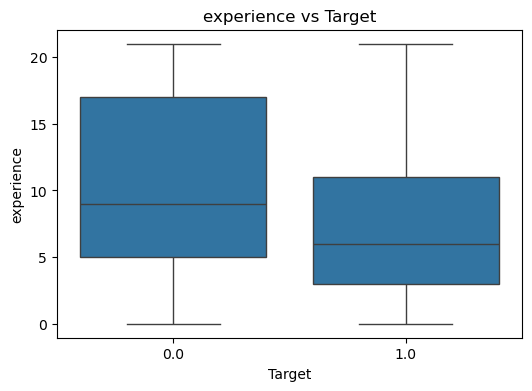

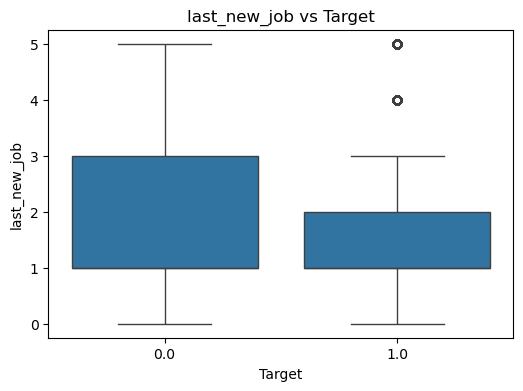

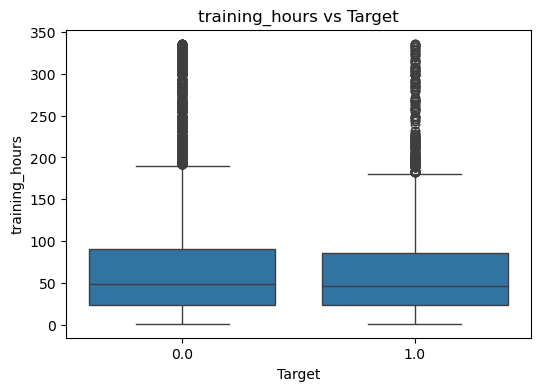

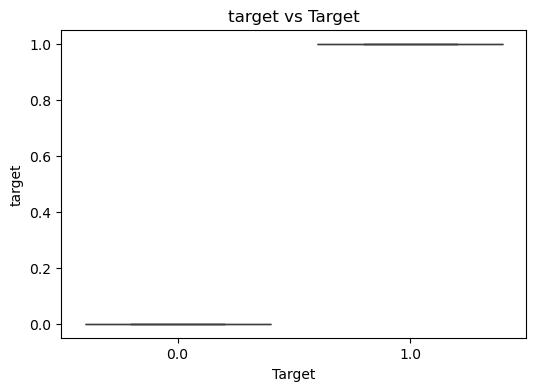

In [34]:
# Numeric vs target (boxplots)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.show()

### Categorical Features vs Target
For categorical variables, I want to see how the target rate changes by category.

This can reveal patterns like:
- certain education levels are more likely to be job searching
- certain company sizes correlate with job change interest

target,0.0,1.0
city,,
city_171,0.000000,100.000000
city_139,20.000000,80.000000
city_155,21.428571,78.571429
city_42,30.769231,69.230769
city_107,33.333333,66.666667
city_33,35.294118,64.705882
city_179,40.000000,60.000000
city_11,40.485830,59.514170
city_21,40.895633,59.104367


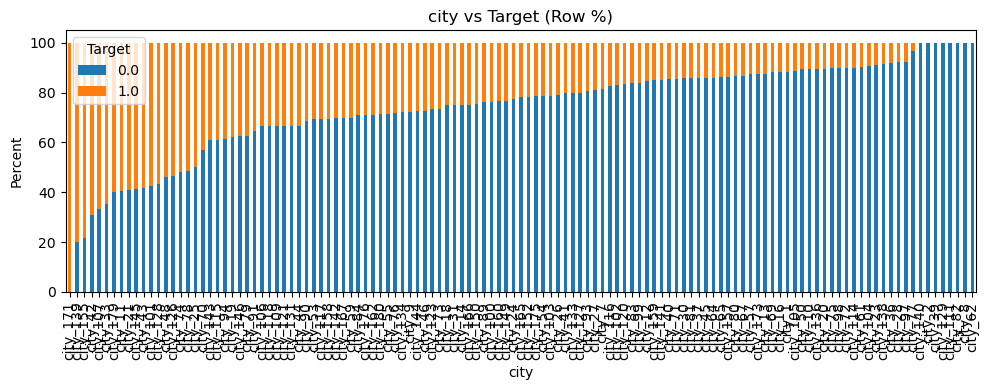

target,0.0,1.0
gender,,
Unknown,69.188110,30.811890
Female,73.667205,26.332795
Other,73.821990,26.178010
Male,77.218062,22.781938


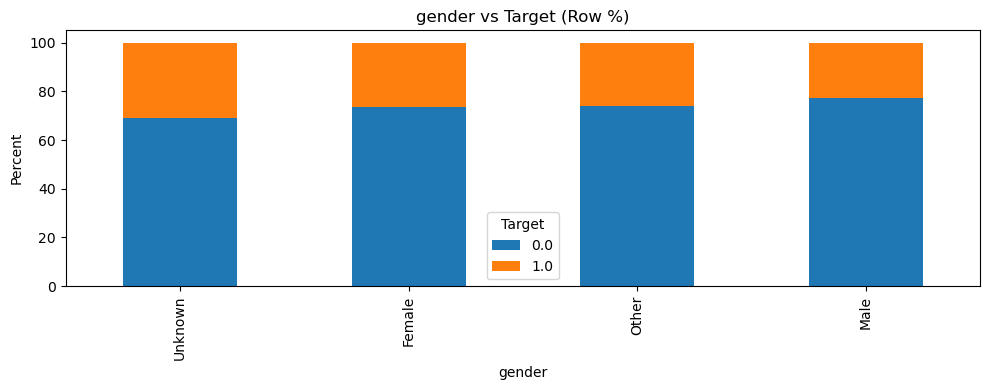

target,0.0,1.0
relevent_experience,,
No relevent experience,66.157287,33.842713
Has relevent experience,78.531032,21.468968


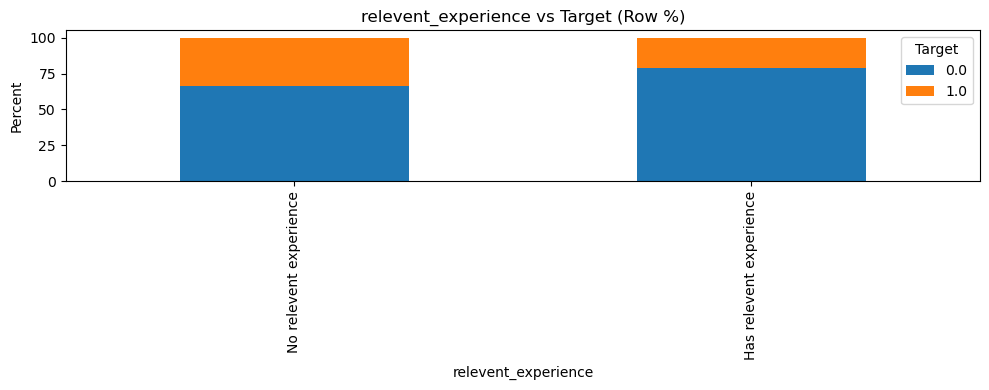

target,0.0,1.0
enrolled_university,,
Full time course,61.911099,38.088901
Unknown,68.134715,31.865285
Part time course,74.791319,25.208681
no_enrollment,78.859376,21.140624


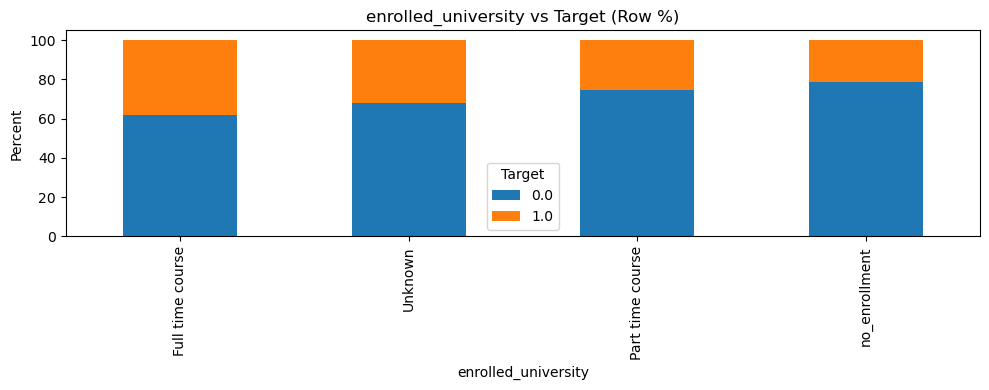

target,0.0,1.0
education_level,,
Graduate,72.021038,27.978962
Unknown,77.391304,22.608696
Masters,78.559963,21.440037
High School,80.466039,19.533961
Phd,85.990338,14.009662
Primary School,86.688312,13.311688


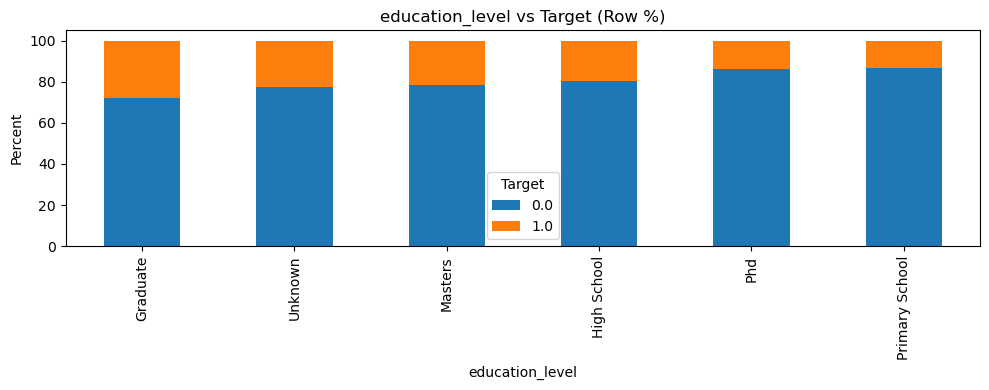

target,0.0,1.0
major_discipline,,
Other,73.228346,26.771654
Business Degree,73.700306,26.299694
STEM,73.840740,26.159260
No Major,75.336323,24.663677
Humanities,78.923767,21.076233
Arts,79.051383,20.948617
Unknown,80.483470,19.516530


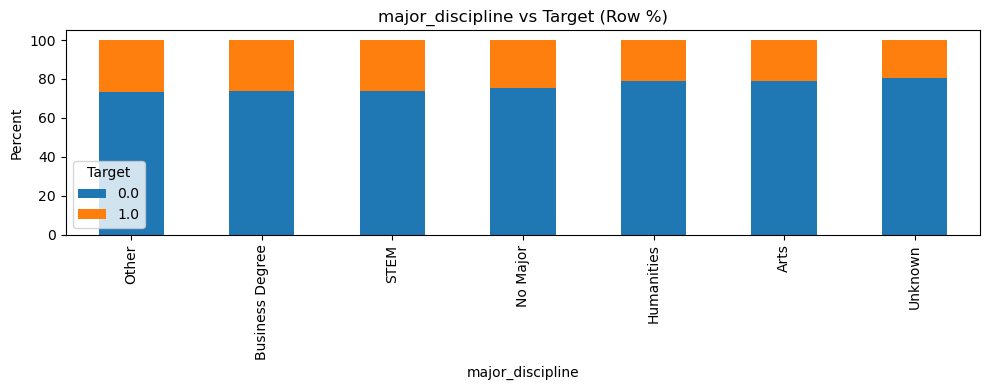

target,0.0,1.0
company_size,,
Unknown,59.413944,40.586056
10/49,76.614548,23.385452
10000+,80.931154,19.068846
5000-9999,81.882771,18.117229
50-99,82.322413,17.677587
500-999,82.668187,17.331813
<10,82.874618,17.125382
100-500,83.858421,16.141579
1000-4999,84.939759,15.060241


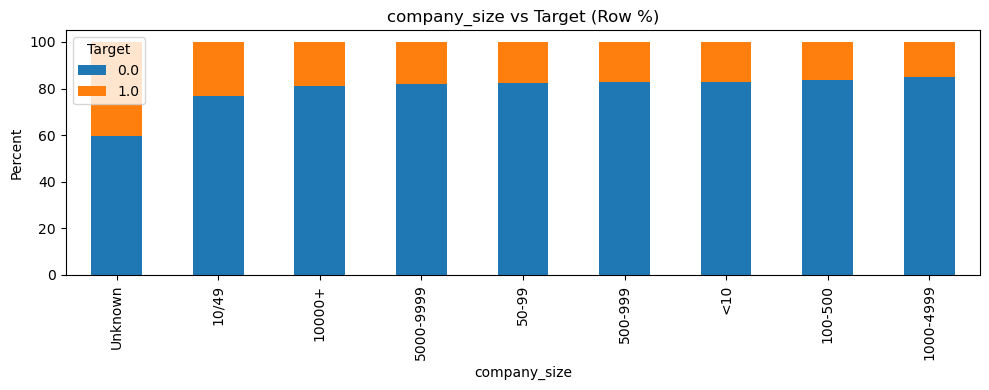

target,0.0,1.0
company_type,,
Unknown,61.172638,38.827362
Other,76.033058,23.966942
Early Stage Startup,76.451078,23.548922
Public Sector,78.010471,21.989529
NGO,81.381958,18.618042
Pvt Ltd,81.919120,18.080880
Funded Startup,86.013986,13.986014


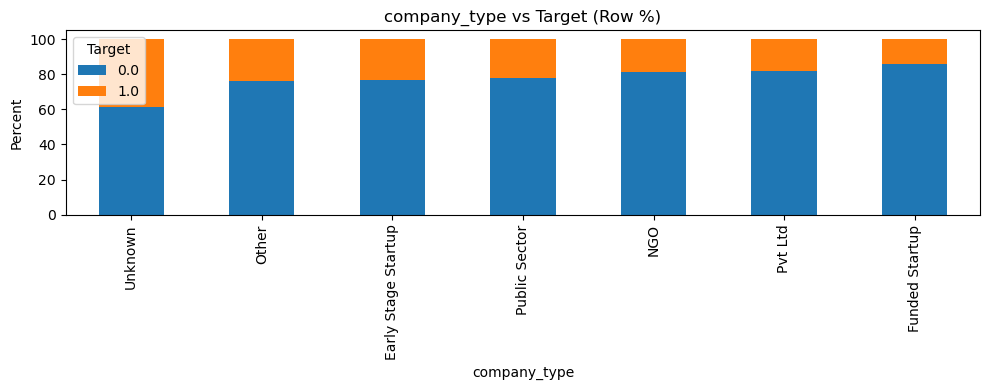

In [35]:
# Categorical vs target (stacked proportions)
for col in cat_cols:
    ct = pd.crosstab(df[col], df["target"], normalize="index") * 100
    ct = ct.sort_values(by=1.0 if 1.0 in ct.columns else 1, ascending=False)

    display(ct.head(10))

    ct.plot(kind="bar", stacked=True, figsize=(10,4))
    plt.title(f"{col} vs Target (Row %)")
    plt.ylabel("Percent")
    plt.legend(title="Target")
    plt.tight_layout()
    plt.show()

### Correlation Heatmap (Numeric Only)
Correlation helps spot:
- numeric features that move together (possible multicollinearity)
- features that may be redundant

This is mostly helpful for linear models like logistic regression.

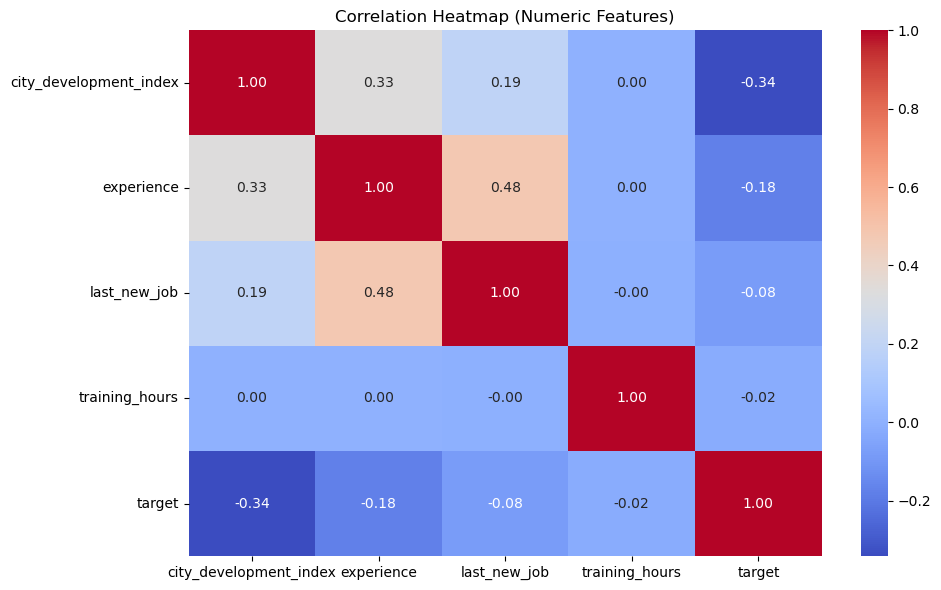

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

## EDA Observations and What Stood Out

After going through the distributions, boxplots, stacked bar charts, and the heatmap, a few patterns really stood out to me.

---

### Target Balance

The dataset is clearly imbalanced. About 75% of candidates are not looking for a job (0), while roughly 25% are actively looking (1). 

This isn’t extreme imbalance, but it’s enough that I can’t rely on accuracy alone later. If a model predicts “not looking” for everyone, it would already be 75% accurate. Because of that, I’ll need to focus more on recall, precision, F1-score, and ROC-AUC when evaluating models.

---

### Numeric Features

#### city_development_index

This was the strongest numeric signal in the entire dataset. The correlation with the target is -0.34, which is noticeably stronger than the other numeric features.

From the boxplots, it’s clear that candidates who are actively looking tend to come from cities with lower development index values. That makes intuitive sense — fewer opportunities locally could push people to search for new jobs.

This feature looks genuinely important.

---

#### experience

Experience also shows a meaningful negative relationship with the target (-0.18). 

From the boxplots, candidates who are looking for jobs generally have fewer years of experience. That aligns with real-world behavior — early-career professionals tend to move around more often.

This doesn’t look as strong as city_development_index, but it definitely matters.

---

#### last_new_job

The relationship here is weaker (-0.08), but still slightly negative. People who changed jobs more recently seem somewhat more likely to be looking again.

There’s also a moderate correlation (0.48) between experience and last_new_job, which makes sense — more experienced people tend to have had more job transitions.

It’s not a dominant feature, but it could still contribute when combined with others.

---

#### training_hours

Training hours had almost no correlation with the target (-0.02). Even though it has a wide range and some big outliers, it doesn’t appear to directly influence whether someone is job hunting.

It might still help in nonlinear models, but on its own, it doesn’t seem very predictive.

---

### Categorical Features

Several categorical variables showed interesting behavioral patterns.

#### relevent_experience

Candidates without relevant experience appear more likely to be looking for a new job. This feels logical — people trying to break into a field may be actively searching.

This variable looks meaningful.

---

#### enrolled_university

Full-time students show higher job-search percentages compared to those not enrolled. That suggests students may be preparing for transitions into the workforce.

---

#### company_size

The “Unknown” company size category has a noticeably higher job-switching percentage. Smaller companies (like 10–49 employees) also show elevated switching compared to very large firms.

This suggests company environment may influence stability.

---

#### company_type

Startup-related categories (Early Stage, Funded Startup) show higher job-search rates compared to more traditional company types like Pvt Ltd.

That fits with what we’d expect — startup environments tend to have higher turnover.

---

#### education_level & major_discipline

These variables show differences, but not dramatic ones. Graduate and Masters dominate the dataset, and while some categories show slightly higher switching percentages, they don’t appear to be strong standalone predictors.

---

### Correlation Heatmap Takeaways

Looking at the numeric heatmap:

- city_development_index has the strongest relationship with the target.
- experience has a moderate effect.
- last_new_job is weak.
- training_hours is almost unrelated.
- No extreme multicollinearity is present (highest inter-feature correlation is 0.48).

Overall, nothing looks dangerously redundant.

---

## Overall Impression from EDA

From everything I’ve seen:

The strongest signals so far appear to be:
- city_development_index
- experience
- relevent_experience
- company_size
- company_type
- enrolled_university

Training hours and major discipline appear weaker on their own.

The dataset shows clear behavioral patterns, and the relationships aren’t random. That’s a good sign — it means modeling should be meaningful rather than guessing.

The next logical step is to properly encode categorical variables and build baseline models to see how these patterns translate into predictive performance.

# Feature Engineering

Based on insights from EDA, I will improve the dataset before modeling.

The goal of feature engineering is to:
- Reduce noise
- Improve signal strength
- Make relationships easier for models to learn
- Handle skewness and category imbalance properly

## Handling Skewed Features

The training_hours variable is strongly right-skewed with extreme outliers.
To reduce skewness and compress large values, I will apply a log transformation.

In [39]:
import numpy as np

df["training_hours_log"] = np.log1p(df["training_hours"])    

## Experience Stability Feature

Since experience and last_new_job are related, I will create a feature that captures
how frequently someone changes jobs relative to their total experience.

In [40]:
df["job_change_ratio"] = df["last_new_job"] / (df["experience"] + 1)

In [41]:
rare_threshold = 300

value_counts = df["major_discipline"].value_counts()
rare_categories = value_counts[value_counts < rare_threshold].index

df["major_discipline"] = df["major_discipline"].replace(rare_categories, "Other")

In [42]:
size_order = {
    "<10": 1,
    "10/49": 2,
    "50-99": 3,
    "100-500": 4,
    "500-999": 5,
    "1000-4999": 6,
    "5000-9999": 7,
    "10000+": 8,
    "Unknown": 0
}

df["company_size_ord"] = df["company_size"].map(size_order)

In [43]:
df = df.drop(["training_hours"], axis=1)

## Feature Engineering Summary

The following transformations were applied:

- Log transformation on training_hours to reduce skew
- Created job_change_ratio to capture career stability
- Grouped rare categories into "Other"
- Ordinal encoded company_size to preserve ordering

These changes were made based on EDA findings and are expected to improve model performance.

## Final Data Validation (After Feature Engineering)

Before model building, I’m doing a final sanity check to make sure the dataset is clean and usable:

- No missing values
- No infinite values (can happen after ratios/logs)
- Numeric columns are truly numeric
- Quick scan of engineered features to confirm they look reasonable

In [47]:
# 1) Shape + missing values (should be 0 total missing)
print("Shape:", df.shape)

missing_total = df.isna().sum().sum()
print("Total missing values:", missing_total)

# Show any columns with missing (if any)
missing_by_col = df.isna().sum().sort_values(ascending=False)
display(missing_by_col[missing_by_col > 0])

Shape: (19158, 15)
Total missing values: 0


Series([], dtype: int64)

In [48]:
import numpy as np

# 2) Check infinite values ONLY on numeric columns
num_df = df.select_dtypes(include=["int64", "float64"])

inf_by_col = np.isinf(num_df).sum().sort_values(ascending=False)
print("Total infinite values:", int(inf_by_col.sum()))
display(inf_by_col[inf_by_col > 0])

Total infinite values: 0


Series([], dtype: int64)

In [49]:
# Replace inf/-inf with NaN then re-impute numeric columns with median
df.replace([np.inf, -np.inf], np.nan, inplace=True)

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("After inf cleanup:")
print("Total missing values:", df.isna().sum().sum())
print("Total infinite values:", int(np.isinf(df.select_dtypes(include=['int64','float64'])).sum().sum()))

After inf cleanup:
Total missing values: 0
Total infinite values: 0


### Engineered Feature Sanity Check

Now I’m quickly checking my engineered features to make sure they have reasonable ranges and didn’t introduce anything weird.

In [50]:
# If these columns exist, summarize them
check_cols = [c for c in ["training_hours_log", "job_change_ratio"] if c in df.columns]

if len(check_cols) == 0:
    print("No engineered columns found (training_hours_log/job_change_ratio). Skipping.")
else:
    display(df[check_cols].describe())

,training_hours_log,job_change_ratio
count,19158.000000,19158.000000
mean,3.800201,0.224147
std,0.944919,0.281477
min,0.693147,0.000000
25%,3.178054,0.083333
50%,3.871201,0.166667
75%,4.488636,0.277778
max,5.820083,5.000000


In [51]:
print("Numeric columns:")
display(df.select_dtypes(include=["int64","float64"]).columns)

print("\nCategorical columns:")
display(df.select_dtypes(include=["object"]).columns)

Numeric columns:


Index(['city_development_index', 'experience', 'last_new_job', 'target',
       'training_hours_log', 'job_change_ratio', 'company_size_ord'],
      dtype='object')


Categorical columns:


Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'company_size', 'company_type'],
      dtype='object')

### Remove Redundant Columns After Feature Engineering

Now that I created engineered features, I want to remove original columns that are no longer needed:

- Drop `company_size` since I created `company_size_ord`
- Drop `city` if using `city_development_index`
- Ensure `training_hours` is removed since I created a log version

This prevents duplication and reduces noise before modeling.

In [52]:
# Drop redundant columns if they exist
cols_to_drop = []

if "company_size" in df.columns:
    cols_to_drop.append("company_size")

if "city" in df.columns and "city_development_index" in df.columns:
    cols_to_drop.append("city")

if "training_hours" in df.columns:
    cols_to_drop.append("training_hours")

df.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns:", cols_to_drop)
df.columns

Dropped columns: ['company_size', 'city']


Index(['city_development_index', 'gender', 'relevent_experience',
       'enrolled_university', 'education_level', 'major_discipline',
       'experience', 'company_type', 'last_new_job', 'target',
       'training_hours_log', 'job_change_ratio', 'company_size_ord'],
      dtype='object')

### Encode Categorical Variables

Before model training, all categorical columns must be converted to numeric format.

I will apply one-hot encoding to the remaining categorical features to allow models to properly learn from them.

In [53]:
# Separate target first
target_col = "target"

# Identify categorical columns (excluding target)
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col]

print("Categorical columns to encode:", cat_cols)

# One-hot encode
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df.head()

Categorical columns to encode: ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_type']


,city_development_index,experience,last_new_job,target,training_hours_log,job_change_ratio,company_size_ord,gender_Male,gender_Other,gender_Unknown,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_Unknown,enrolled_university_no_enrollment,education_level_High School,education_level_Masters,education_level_Phd,education_level_Primary School,education_level_Unknown,major_discipline_Humanities,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,0.920,21.0,1.0,1.0,3.610918,0.045455,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
1,0.776,15.0,5.0,0.0,3.871201,0.312500,3,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
2,0.624,5.0,0.0,0.0,4.430817,0.000000,0,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
3,0.789,0.0,0.0,1.0,3.970292,0.000000,0,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,0.767,21.0,4.0,0.0,2.197225,0.181818,3,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False


### Ensure Target Variable Is Integer

For classification models, the target variable should be integer (0 and 1).

In [54]:
df["target"] = df["target"].astype(int)

print("Target dtype:", df["target"].dtype)
print(df["target"].value_counts())

Target dtype: int64
target
0    14381
1     4777
Name: count, dtype: int64


### Final Data Type Check (Model-Ready Confirmation)

At this stage:
- No missing values
- No infinite values
- All columns numeric
- Target is integer

If this check passes, the dataset is ready for modeling.

In [55]:
print("Final shape:", df.shape)
print("\nData types:")
print(df.dtypes.value_counts())

# Confirm no object columns remain
object_cols = df.select_dtypes(include="object").columns
print("\nRemaining object columns:", list(object_cols))

Final shape: (19158, 29)

Data types:
bool       22
float64     5
int64       2
Name: count, dtype: int64

Remaining object columns: []


## Final Data Preparation Summary

The original dataset required several preprocessing and optimization steps before modeling:

1. Missing values were identified and imputed using appropriate strategies (median for numeric features).
2. Data types were corrected to ensure numeric modeling compatibility.
3. Skewed features (training_hours) were transformed using a log transformation.
4. Rare categorical values were grouped to reduce noise.
5. An ordinal encoding strategy was applied to company_size to preserve ordering.
6. A job_change_ratio feature was engineered to capture career stability.
7. All categorical variables were encoded using one-hot encoding.
8. Final validation confirmed:
   - No missing values
   - No infinite values
   - All features numeric
   - Target variable correctly formatted

The dataset is now optimized and ready for machine learning model development.

### Considered but Not Implemented

Several additional feature engineering techniques were considered:

- Feature scaling (to be applied during modeling phase)
- Interaction terms between categorical variables
- Advanced outlier removal

These were not implemented at this stage because:
- Tree-based models are robust to scaling
- Over-engineering may introduce unnecessary noise
- The dataset was already well-behaved after transformation